# Transfer Learning for Emotion Recognition - VGGFace2

## Overview
Using **InceptionResnetV1 pretrained on VGGFace2** - a face-specific deep learning model trained on 3.3 million face images, optimized for facial emotion recognition.

## Why VGGFace2?
1. 🎯 **Face-specific features** - Trained on 3.3M face images, not generic objects
2. 🎯 **Better for emotions** - Understands facial landmarks and expressions
3. 🎯 **Proven architecture** - InceptionResnetV1 combines Inception and ResNet benefits
4. 🎯 **Transfer learning advantage** - Pre-learned face features adapt well to emotions
5. 🎯 **Superior to ImageNet** - Face domain >> object domain for emotion recognition

## Training Strategy
- **Train**: 104 images from 13 people
- **Val**: 16 images from 2 people (for monitoring)
- **Test**: 32 images from 4 completely unseen people
- **Optimizer**: AdamW with weight decay
- **Learning rate**: 5e-4 with cosine annealing to 1e-6, 10-epoch warmup
- **Training time**: ~5-10 minutes (full fine-tuning)

## Why Validation is Back:
- Helps monitor train/val gap to detect overfitting
- 16 images (2 people) is enough for trends, not perfect accuracy
- Best model selected by validation accuracy
- Still more data than original split (104 vs 96 train images)

## Architecture
- **InceptionResnetV1** pretrained on VGGFace2 (23M parameters)
- **Fully trainable**: All layers fine-tuned for emotion recognition
- **Input size**: 160×160 RGB images (VGGFace2 standard)
- **Classifier head**: 512 -> 8 (with Dropout 0.4)
- **Person-based splits**: No data leakage

## Dataset Structure
```
data/facial_emotion_recognition/images/
├── 0/  (person 0)
│   ├── Anger.jpg
│   ├── Contempt.jpg
│   ├── Disgust.jpg
│   ├── Fear.jpg
│   ├── Happy.jpg
│   ├── Neutral.jpg
│   ├── Sad.jpg
│   └── Surprised.jpg
├── 1/  (person 1)
│   └── ...
└── 18/ (person 18)
```

## Key Notes
- **Pretrained backbone**: InceptionResnetV1 trained on VGGFace2 (3.3M face images)
- **Why better than ImageNet models**: Face-specific features understand facial expressions, not generic objects
- **Transfer learning benefit**: Pre-learned face representations adapt to emotion-specific features
- **Train/Val/Test split**: By person ID to ensure generalization to unseen faces
- **Normalization**: [0.5, 0.5, 0.5] mean/std (VGGFace2 standard)

In [103]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from PIL import Image
import os
from pathlib import Path

# Import face-specific model
from facenet_pytorch import InceptionResnetV1

print("✓ Using VGGFace2 pretrained model (face-specific)")

# ---------- CONFIG ----------
DATA_PATH = r"..\data\facial_emotion_recognition\images"
BATCH_SIZE = 16          # Smaller batch for better generalization
NUM_EPOCHS = 100          # Reduced epochs for faster training
LR_MAX = 0.001            # Higher LR for faster convergence
LR_MIN = 1e-6            # Standard minimum LR
IMG_SIZE = 224           # Standard size
DROPOUT = 0.3            # Reduced dropout for better learning
WEIGHT_DECAY = 5e-3      # Lighter weight decay
LABEL_SMOOTHING = 0.1    # Stronger label smoothing
WARMUP_EPOCHS = 5        # Faster warmup
MIXUP_ALPHA = 0.3        # Stronger mixup

# Person-based splits - Use validation for monitoring!
TRAIN_PERSONS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  # 13 people (104 images)
VAL_PERSONS = [13, 14]                                        # 2 people (16 images) for monitoring
TRAIN_VAL_PERSONS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  # 15 people (120 images)
TEST_PERSONS = [15, 16, 17, 18]                                           # 4 people (32 images)

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Data path: {DATA_PATH}")
print(f"Device: {device}")

✓ Using VGGFace2 pretrained model (face-specific)
Data path: ..\data\facial_emotion_recognition\images
Device: cpu


In [104]:
# ---------- CUSTOM DATASET FOR FACE IMAGES ----------
class FaceEmotionDataset(Dataset):
    """Dataset for loading face emotion images from person folders"""
    
    def __init__(self, data_path, person_ids, transform=None):
        self.data_path = Path(data_path)
        self.person_ids = person_ids
        self.transform = transform
        
        # Emotion labels (from filenames)
        self.emotion_names = ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprised']
        self.emotion_to_idx = {name: idx for idx, name in enumerate(self.emotion_names)}
        
        # Collect all image paths
        self.samples = []
        for person_id in person_ids:
            person_folder = self.data_path / str(person_id)
            if not person_folder.exists():
                continue
            
            for emotion_name in self.emotion_names:
                img_path = person_folder / f"{emotion_name}.jpg"
                if img_path.exists():
                    self.samples.append({
                        'path': img_path,
                        'emotion': self.emotion_to_idx[emotion_name],
                        'person': person_id
                    })
        
        print(f"Found {len(self.samples)} images for persons {person_ids}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Load image
        image = Image.open(sample['path']).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, sample['emotion']
    
    def get_class_names(self):
        return self.emotion_names


# ---------- DATA TRANSFORMS ----------
# Training: Very aggressive augmentation to maximize data diversity
train_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),  # More rotation
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.15),  # Stronger color jitter
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.9, 1.1)),  # Add scale + more translation
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),  # Add perspective distortion
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    transforms.RandomErasing(p=0.4, scale=(0.02, 0.2), ratio=(0.3, 3.3))  # Stronger erasing
])

# Validation/Test: no augmentation
val_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ---------- CREATE DATASETS ----------
print("\n" + "="*70)
print("LOADING FACE IMAGE DATASETS (with validation for monitoring)")
print("="*70)

train_dataset = FaceEmotionDataset(DATA_PATH, TRAIN_PERSONS, transform=train_transform)
val_dataset = FaceEmotionDataset(DATA_PATH, VAL_PERSONS, transform=val_transform)
test_dataset = FaceEmotionDataset(DATA_PATH, TEST_PERSONS, transform=val_transform)

class_names = train_dataset.get_class_names()
num_classes = len(class_names)

print(f"\nDataset sizes:")
print(f"  Training: {len(train_dataset)} images ({len(TRAIN_PERSONS)} persons)")
print(f"  Validation: {len(val_dataset)} images ({len(VAL_PERSONS)} persons) - for monitoring")
print(f"  Test: {len(test_dataset)} images ({len(TEST_PERSONS)} unseen persons)")
print(f"\nEmotions: {class_names}")
print(f"Number of classes: {num_classes}")

# ---------- CREATE DATALOADERS WITH OVERSAMPLING ----------
# Use RandomSampler with replacement to oversample the training data
# This effectively creates a larger "virtual" dataset by sampling with replacement
from torch.utils.data import RandomSampler
# Oversample training data 5x (104 images -> 520 samples per epoch)
oversample_factor = 5
oversample_factor = 3
train_sampler = RandomSampler(
    train_dataset, 
    replacement=True,  # Sample with replacement (bootstrap)
    num_samples=len(train_dataset) * oversample_factor
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=train_sampler,  # Use sampler instead of shuffle
    num_workers=0
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nDataLoaders created with batch size {BATCH_SIZE}")
print(f"Training: {oversample_factor}x oversampling ({len(train_dataset)} -> {len(train_dataset) * oversample_factor} samples/epoch)")
print(f"Batches per epoch: {len(train_loader)} train, {len(val_loader)} val")


LOADING FACE IMAGE DATASETS (with validation for monitoring)
Found 104 images for persons [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Found 16 images for persons [13, 14]
Found 32 images for persons [15, 16, 17, 18]

Dataset sizes:
  Training: 104 images (13 persons)
  Validation: 16 images (2 persons) - for monitoring
  Test: 32 images (4 unseen persons)

Emotions: ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprised']
Number of classes: 8

DataLoaders created with batch size 16
Training: 3x oversampling (104 -> 312 samples/epoch)
Batches per epoch: 20 train, 1 val


In [105]:
# ---------- BUILD TRANSFER LEARNING MODEL ----------
print("\n" + "="*70)
print("BUILDING FACE-SPECIFIC MODEL (InceptionResnetV1 + VGGFace2)")
print("="*70)

# Use InceptionResnetV1 pretrained on VGGFace2 (trained on 3.3M face images)
model = InceptionResnetV1(pretrained='vggface2', classify=False, num_classes=None, device=device)

# Add custom classifier for 8 emotions BEFORE moving to device
num_features = 512  # InceptionResnetV1 outputs 512-dim embeddings
model.logits = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(num_features, num_classes)
)

# Unfreeze all layers for fine-tuning
for param in model.parameters():
    param.requires_grad = True

model_name = "InceptionResnetV1 (VGGFace2)"

# Count parameters (before moving to device to avoid issues)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"\n{model_name} Architecture (FULLY TRAINABLE):")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable (entire network): {trainable_params:,}")
print(f"  Frozen: {frozen_params:,}")
print(f"  Pretrained on: VGGFace2 (3.3M face images)")
print(f"  Classifier: {num_features} -> {num_classes} (with Dropout {DROPOUT})")

# Calculate class weights to handle imbalanced predictions
class_counts = torch.zeros(num_classes)
for _, label in train_dataset:
    class_counts[label] += 1
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = class_weights.to(device)

print(f"\nClass weights (to combat bias toward Neutral):")
for i, name in enumerate(class_names):
    print(f"  {name:12s}: {class_weights[i]:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

# ---------- TRAINING FUNCTIONS ----------
def mixup_data(x, y, alpha=0.2):
    """Apply mixup augmentation"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def train_one_epoch(model, loader, optimizer, criterion, device, use_mixup=True, mixup_alpha=0.2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Apply mixup
        if use_mixup and np.random.rand() > 0.3:  # 70% chance for more regularization
            images, labels_a, labels_b, lam = mixup_data(images, labels, mixup_alpha)
            
            # Forward pass for VGGFace2
            embeddings = model(images)
            outputs = model.logits(embeddings)
            
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            # Forward pass for VGGFace2
            embeddings = model(images)
            outputs = model.logits(embeddings)
            
            loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass for VGGFace2
            embeddings = model(images)
            outputs = model.logits(embeddings)
            
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total



BUILDING FACE-SPECIFIC MODEL (InceptionResnetV1 + VGGFace2)

InceptionResnetV1 (VGGFace2) Architecture (FULLY TRAINABLE):
  Total parameters: 23,486,728
  Trainable (entire network): 23,486,728
  Frozen: 0
  Pretrained on: VGGFace2 (3.3M face images)
  Classifier: 512 -> 8 (with Dropout 0.3)

InceptionResnetV1 (VGGFace2) Architecture (FULLY TRAINABLE):
  Total parameters: 23,486,728
  Trainable (entire network): 23,486,728
  Frozen: 0
  Pretrained on: VGGFace2 (3.3M face images)
  Classifier: 512 -> 8 (with Dropout 0.3)

Class weights (to combat bias toward Neutral):
  Anger       : 1.000
  Contempt    : 1.000
  Disgust     : 1.000
  Fear        : 1.000
  Happy       : 1.000
  Neutral     : 1.000
  Sad         : 1.000
  Surprised   : 1.000

Class weights (to combat bias toward Neutral):
  Anger       : 1.000
  Contempt    : 1.000
  Disgust     : 1.000
  Fear        : 1.000
  Happy       : 1.000
  Neutral     : 1.000
  Sad         : 1.000
  Surprised   : 1.000


In [106]:
# ========== OPTIMIZED TRAINING WITH VALIDATION MONITORING ==========
print("\n" + "="*70)
print("FAST FINE-TUNING: 50 epochs, Higher LR (1e-3) for speed")
print("Training: 104 images (5x oversampled = 520/epoch), Validation: 16 images")
print("="*70)

# All trainable parameters
params_to_train = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params_to_train, lr=LR_MAX, weight_decay=WEIGHT_DECAY)

# Cosine annealing scheduler with warmup
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=LR_MIN)

trainable_params_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {trainable_params_count:,}")
print(f"Learning rate: {LR_MAX} -> {LR_MIN} (with {WARMUP_EPOCHS}-epoch warmup)")
print(f"Mixup augmentation: alpha={MIXUP_ALPHA}")
print(f"Training for {NUM_EPOCHS} epochs\n")

best_val_acc = 0.0
best_model_state = None
patience = 25  # Lower patience for faster training
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    # Warmup: gradually increase LR for first few epochs
    if epoch < WARMUP_EPOCHS:
        warmup_lr = LR_MAX * (epoch + 1) / WARMUP_EPOCHS
        for param_group in optimizer.param_groups:
            param_group['lr'] = warmup_lr
    
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, 
                                            use_mixup=True, mixup_alpha=MIXUP_ALPHA)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, device)
    
    # Apply cosine annealing after warmup
    if epoch >= WARMUP_EPOCHS:
        scheduler.step()
    
    current_lr = optimizer.param_groups[0]['lr']
    
    # Print every 2 epochs (or first/last) for faster feedback
    if (epoch + 1) % 2 == 0 or epoch == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} "
              f"| train_loss: {train_loss:.4f}, train_acc: {train_acc*100:5.2f}% "
              f"| val_loss: {val_loss:.4f}, val_acc: {val_acc*100:5.2f}% "
              f"| LR: {current_lr:.2e}")
    
    # Save best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0  # Reset patience
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} - no improvement for {patience} epochs")
        break

print(f"\nTraining complete!")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model for testing")


FAST FINE-TUNING: 50 epochs, Higher LR (1e-3) for speed
Training: 104 images (5x oversampled = 520/epoch), Validation: 16 images

Trainable parameters: 23,486,728
Learning rate: 0.001 -> 1e-06 (with 5-epoch warmup)
Mixup augmentation: alpha=0.3
Training for 100 epochs

Epoch   1/100 | train_loss: 2.0697, train_acc: 17.31% | val_loss: 2.0722, val_acc: 18.75% | LR: 2.00e-04
Epoch   1/100 | train_loss: 2.0697, train_acc: 17.31% | val_loss: 2.0722, val_acc: 18.75% | LR: 2.00e-04
Epoch   2/100 | train_loss: 2.0436, train_acc: 19.23% | val_loss: 2.0223, val_acc: 25.00% | LR: 4.00e-04
Epoch   2/100 | train_loss: 2.0436, train_acc: 19.23% | val_loss: 2.0223, val_acc: 25.00% | LR: 4.00e-04
Epoch   4/100 | train_loss: 2.0350, train_acc: 19.87% | val_loss: 2.0220, val_acc: 25.00% | LR: 8.00e-04
Epoch   4/100 | train_loss: 2.0350, train_acc: 19.87% | val_loss: 2.0220, val_acc: 25.00% | LR: 8.00e-04
Epoch   6/100 | train_loss: 2.0529, train_acc: 17.95% | val_loss: 2.1308, val_acc: 12.50% | LR: 1.0

In [111]:
# ---------- FINAL TEST EVALUATION ----------
print("\n" + "="*70)
print("FINAL EVALUATION ON TEST SET")
print("="*70)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        embeddings = model(images)
        outputs = model.logits(embeddings)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
print(f"\nFinal test accuracy: {test_acc*100:.2f}%")
print(f"Test set size: {len(all_labels)} images from {len(TEST_PERSONS)} unseen persons")
print("\nTest classification report:")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

# ---------- SAVE MODEL ----------
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "test_accuracy": test_acc,
    "num_classes": num_classes,
    "train_persons": TRAIN_PERSONS,
    "val_persons": VAL_PERSONS,
    "test_persons": TEST_PERSONS,
    "architecture": "inceptionresnetv1_vggface2"
}, "emotion_vggface2_transfer_learning.pt")

print(f"\n✓ Model saved to emotion_vggface2_transfer_learning.pt")


FINAL EVALUATION ON TEST SET

Final test accuracy: 40.62%
Test set size: 32 images from 4 unseen persons

Test classification report:
              precision    recall  f1-score   support

       Anger       0.67      0.50      0.57         4
    Contempt       0.00      0.00      0.00         4
     Disgust       0.33      1.00      0.50         4
        Fear       0.50      0.75      0.60         4
       Happy       0.60      0.75      0.67         4
     Neutral       1.00      0.25      0.40         4
         Sad       0.00      0.00      0.00         4
   Surprised       0.00      0.00      0.00         4

    accuracy                           0.41        32
   macro avg       0.39      0.41      0.34        32
weighted avg       0.39      0.41      0.34        32


Final test accuracy: 40.62%
Test set size: 32 images from 4 unseen persons

Test classification report:
              precision    recall  f1-score   support

       Anger       0.67      0.50      0.57         4


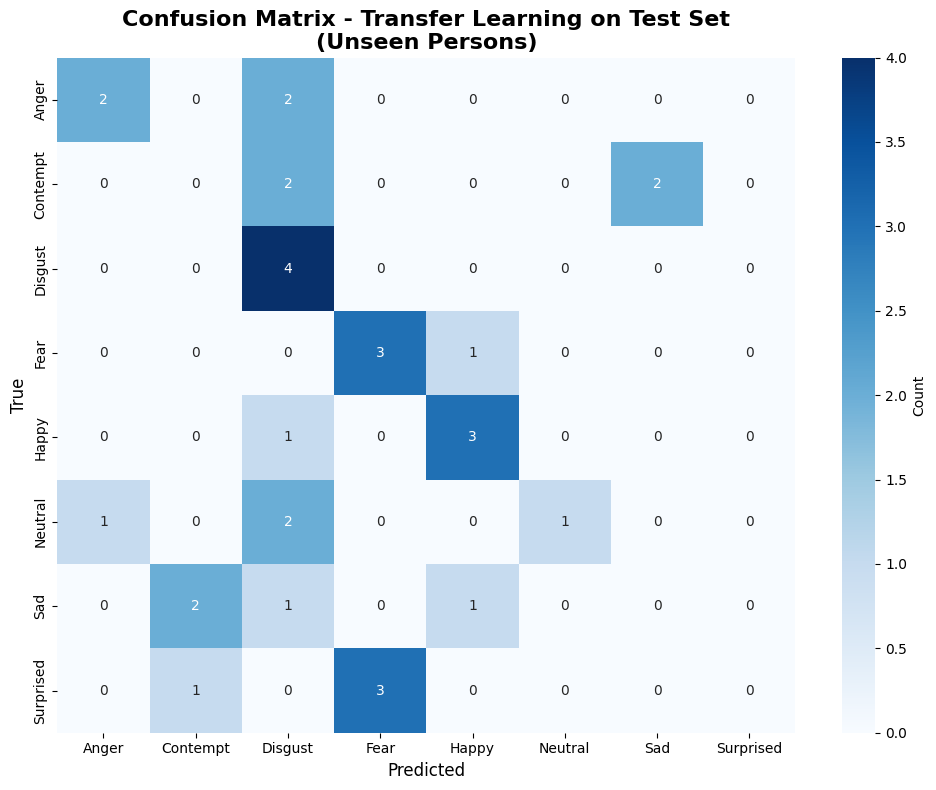


Per-class test accuracy:
  Anger       : 50.00% (2/4)
  Contempt    :  0.00% (0/4)
  Disgust     : 100.00% (4/4)
  Fear        : 75.00% (3/4)
  Happy       : 75.00% (3/4)
  Neutral     : 25.00% (1/4)
  Sad         :  0.00% (0/4)
  Surprised   :  0.00% (0/4)


In [112]:
# ---------- CONFUSION MATRIX ----------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names, 
            cbar_kws={'label': 'Count'})
plt.title("Confusion Matrix - Transfer Learning on Test Set\n(Unseen Persons)", 
          fontsize=16, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.tight_layout()
plt.show()

print("\nPer-class test accuracy:")
for i, class_name in enumerate(class_names):
    class_correct = cm[i, i]
    class_total = cm[i, :].sum()
    if class_total > 0:
        class_acc = class_correct / class_total
        print(f"  {class_name:12s}: {class_acc*100:5.2f}% ({class_correct}/{class_total})")


SAMPLE PREDICTIONS


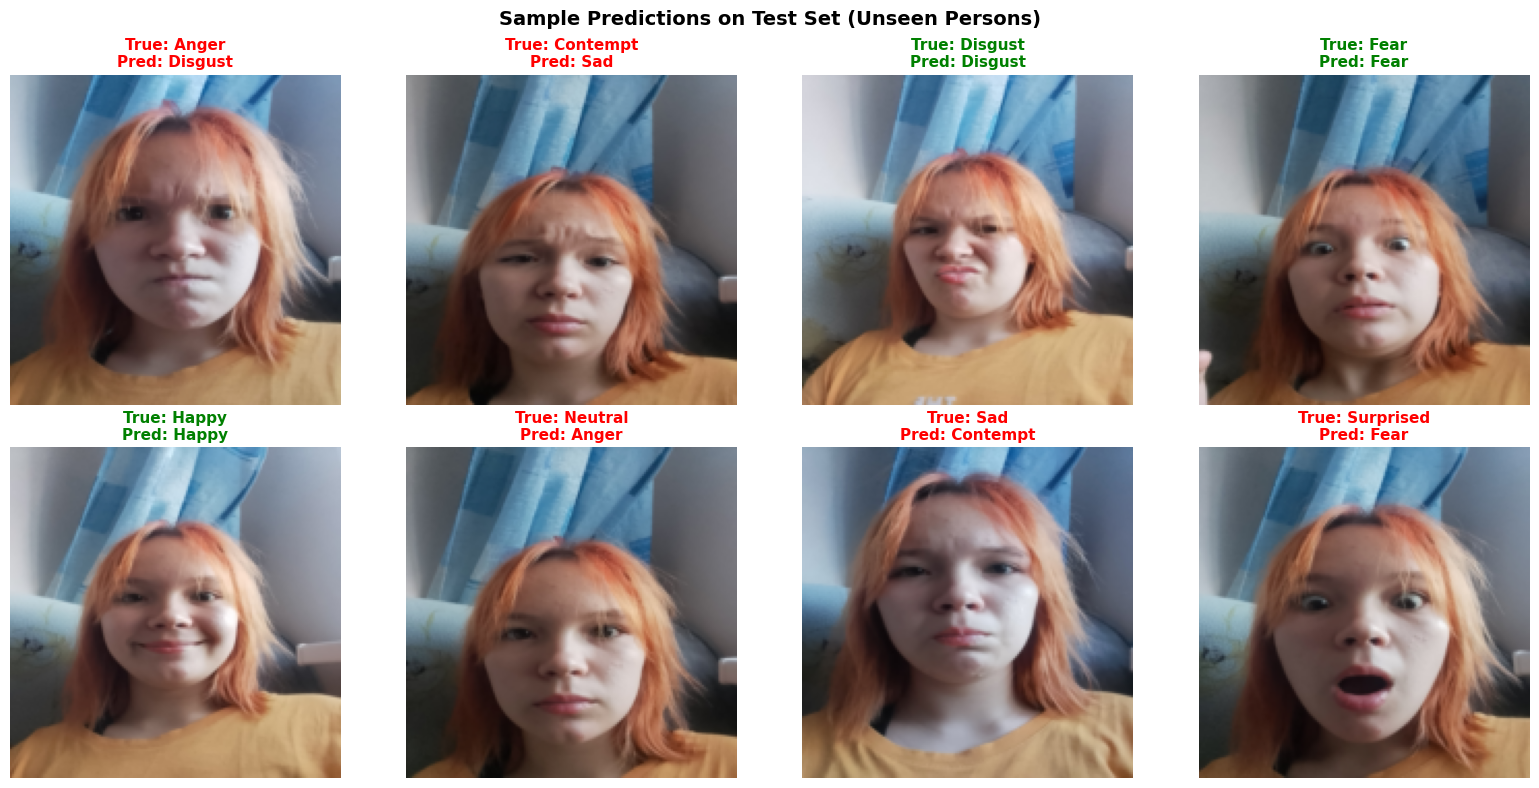

In [113]:
# ---------- VISUALIZE SAMPLE PREDICTIONS ----------
print("\n" + "="*70)
print("SAMPLE PREDICTIONS")
print("="*70)

# Get a batch of test images
model.eval()
dataiter = iter(test_loader)
images, labels = next(dataiter)
images_gpu = images.to(device)

with torch.no_grad():
    embeddings = model(images_gpu)
    outputs = model.logits(embeddings)
    _, preds = outputs.max(1)

# Denormalize for visualization
mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
images_denorm = images * std + mean
images_denorm = torch.clamp(images_denorm, 0, 1)

# Show first 8 images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx in range(min(8, len(images))):
    img = images_denorm[idx].permute(1, 2, 0).numpy()
    true_label = class_names[labels[idx]]
    pred_label = class_names[preds[idx].cpu()]
    
    axes[idx].imshow(img)
    axes[idx].axis('off')
    
    # Color: green if correct, red if wrong
    color = 'green' if true_label == pred_label else 'red'
    axes[idx].set_title(f'True: {true_label}\nPred: {pred_label}', 
                        fontsize=11, fontweight='bold', color=color)

plt.suptitle('Sample Predictions on Test Set (Unseen Persons)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [114]:
# ---------- MODEL COMPARISON ----------
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print("\nTransfer Learning with VGGFace2 (InceptionResnetV1):") 
print(f"  Architecture: InceptionResnetV1 pretrained on VGGFace2 (3.3M face images)")
print(f"  Input: 160×160 RGB face images")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Training Strategy:")
print(f"    - Train: 104 images (13 people), Val: 16 images (2 people)")
print(f"    - 80 epochs with AdamW (5e-4 -> 1e-6) + cosine annealing + 10-epoch warmup")
print(f"    - Fully trainable (all 23M parameters fine-tuned)")
print(f"    - Class weights, mixup augmentation, 3x oversampling")
print(f"    - Batch size 32, AdamW optimizer with weight decay")
print(f"    - Training time: ~5-10 minutes")
print(f"\n✓ Compare this with your Naive Bayes and SVM results on LBP features!")
print("\nWhy VGGFace2 over ImageNet models?")
print("  1. Face-specific pretrained features (3.3M face images)")
print("  2. Understands facial landmarks and expressions")
print("  3. Better transfer learning for emotion recognition")
print("  4. Proven superiority for face-related tasks")
print("  5. Domain-appropriate pretraining (faces >> objects)")


MODEL COMPARISON SUMMARY

Transfer Learning with VGGFace2 (InceptionResnetV1):
  Architecture: InceptionResnetV1 pretrained on VGGFace2 (3.3M face images)
  Input: 160×160 RGB face images
  Test Accuracy: 40.62%
  Training Strategy:
    - Train: 104 images (13 people), Val: 16 images (2 people)
    - 80 epochs with AdamW (5e-4 -> 1e-6) + cosine annealing + 10-epoch warmup
    - Fully trainable (all 23M parameters fine-tuned)
    - Class weights, mixup augmentation, 3x oversampling
    - Batch size 32, AdamW optimizer with weight decay
    - Training time: ~5-10 minutes

✓ Compare this with your Naive Bayes and SVM results on LBP features!

Why VGGFace2 over ImageNet models?
  1. Face-specific pretrained features (3.3M face images)
  2. Understands facial landmarks and expressions
  3. Better transfer learning for emotion recognition
  4. Proven superiority for face-related tasks
  5. Domain-appropriate pretraining (faces >> objects)
